In [ ]:
!pip -q install ucimlrepo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# Pobieram zbiór User Knowledge Modeling z repozytorium UCI
dataset = fetch_ucirepo(id=257)

# Cechy wejściowe
X_raw = dataset.data.features

# Zmienna decyzyjna
y_raw = dataset.data.targets

# Łącze wszystko w jeden DataFrame dla wygodniejszej analizy
#axis=1 laczenie kolumnami
df = pd.concat([X_raw, y_raw], axis=1)

# wyswietlenie pierwszych wierszy
df.head()

,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,very_low
1,0.08,0.08,0.10,0.24,0.90,High
2,0.06,0.06,0.05,0.25,0.33,Low
3,0.10,0.10,0.15,0.65,0.30,Middle
4,0.08,0.08,0.08,0.98,0.24,Low


In [ ]:
# W danych występował problem z niespójnym zapisem jednej klasy:
# "Very Low" oraz "very_low"
# Dla komputera są to dwie różne etykiety, więc trzeba je ujednolicić.

df["UNS"] = df["UNS"].astype(str).str.strip()          # usuwam zbędne spacje
df["UNS"] = df["UNS"].str.lower()                      # zamieniam na małe litery
df["UNS"] = df["UNS"].replace({"very low": "very_low"})  # ujednolicam zapis

# Przywracam estetyczne nazwy klas do raportu
df["UNS"] = df["UNS"].map({
    "low": "Low",
    "middle": "Middle",
    "high": "High",
    "very_low": "Very Low"
})

print("Liczba klas po ujednoliceniu:", df["UNS"].nunique())
print("\nRozkład klas:")
print(df["UNS"].value_counts())

Liczba klas po ujednoliceniu: 4

Rozkład klas:
UNS
Low         129
Middle      122
High        102
Very Low     50
Name: count, dtype: int64


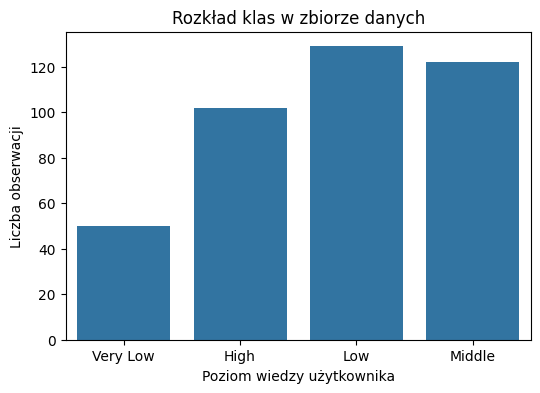

In [ ]:

# ROZKŁAD KLAS W ZBIORZE DANYCH

#zakres wykresu rozmiar 6x4
plt.figure(figsize=(6,4))
#ryzowanie slupkow liczebnosci klas
sns.countplot(data=df, x="UNS")

plt.title("Rozkład klas w zbiorze danych")
plt.xlabel("Poziom wiedzy użytkownika")
plt.ylabel("Liczba obserwacji")

plt.show()

In [ ]:
print("BRAKI DANYCH\n")

# Liczba braków w każdej kolumnie - gdzie sa i ile
missing_per_column = df.isnull().sum()
print("Braki w kolumnach:")
print(missing_per_column)

# Procent braków
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nProcent braków [%]:")
print(missing_percent)

# Wniosek
if df.isnull().sum().sum() == 0:
    print("\nWniosek: zbiór danych nie zawiera brakujących wartości.")
else:
    print("\nWniosek: w zbiorze występują brakujące dane.")

BRAKI DANYCH

Braki w kolumnach:
STG    0
SCG    0
STR    0
LPR    0
PEG    0
UNS    0
dtype: int64

Procent braków [%]:
STG    0.0
SCG    0.0
STR    0.0
LPR    0.0
PEG    0.0
UNS    0.0
dtype: float64

Wniosek: zbiór danych nie zawiera brakujących wartości.


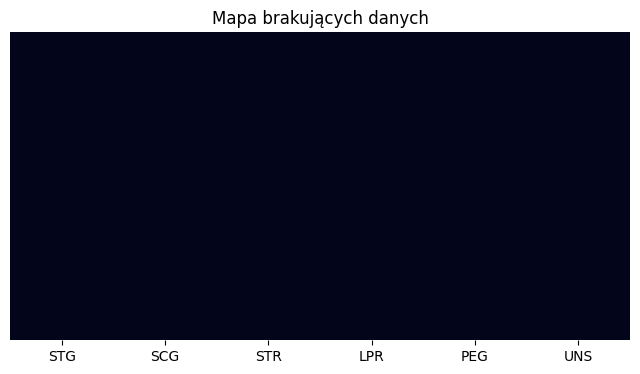

In [ ]:
# Wizualizacja braków danych
plt.figure(figsize=(8, 4))
#cbar - bez kolorow, yticklabels - bez etykiet wierszy
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Mapa brakujących danych")
plt.show()

In [ ]:
#df.shape - pokaz wymiaru tabeli liczba wierszy i kolumn
print("Wymiary zbioru (wiersze, kolumny):", df.shape)

print("\nKolumny:")
print(list(df.columns))

print("\nTypy danych:")
print(df.dtypes)
#usuwanie klasy, statystyki opisowe, .T - transpozycja dla czytelnosci
print("\nStatystyki opisowe cech numerycznych:")
print(df.drop(columns=["UNS"]).describe().T)

Wymiary zbioru (wiersze, kolumny): (403, 6)

Kolumny:
['STG', 'SCG', 'STR', 'LPR', 'PEG', 'UNS']

Typy danych:
STG    float64
SCG    float64
STR    float64
LPR    float64
PEG    float64
UNS     object
dtype: object

Statystyki opisowe cech numerycznych:
     count      mean       std  min    25%   50%   75%   max
STG  403.0  0.353141  0.212018  0.0  0.200  0.30  0.48  0.99
SCG  403.0  0.355940  0.215531  0.0  0.200  0.30  0.51  0.90
STR  403.0  0.457655  0.246684  0.0  0.265  0.44  0.68  0.95
LPR  403.0  0.431342  0.257545  0.0  0.250  0.33  0.65  0.99
PEG  403.0  0.456360  0.266775  0.0  0.250  0.40  0.66  0.99


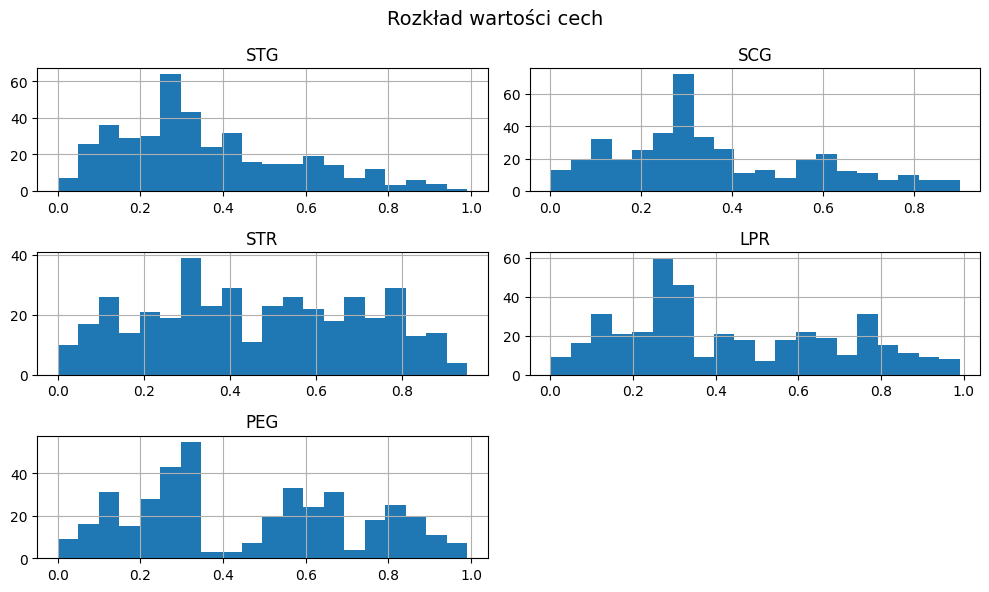

In [ ]:
# ROZKŁAD CECH NUMERYCZNYCH
#20 przedzialow histogramu
#zobaczenie jak rozkladaja sie wartosci cech
df.drop(columns=["UNS"]).hist(figsize=(10, 6), bins=20)
plt.suptitle("Rozkład wartości cech", fontsize=14)
plt.tight_layout()
plt.show()

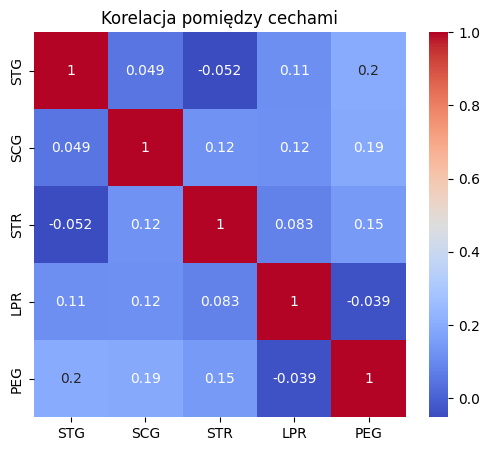

In [ ]:
# KORELACJA CECH


plt.figure(figsize=(6,5))

sns.heatmap(
    #liczenie korelacji miedzy cechami liczbowymi by widziec ktore cechy sa silniejsze
    df.drop(columns=["UNS"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Korelacja pomiędzy cechami")
plt.show()

In [ ]:
# Sprawdzam, czy dla identycznych wartości cech nie występują różne klasy decyzyjne

feature_cols = ["STG", "SCG", "STR", "LPR", "PEG"]

inconsistent = (
    #grupowanie po wszystkich cechach, ile roznych klas wystepuje w kazdej gr
    #.reset_index()- zwykla tabela
    df.groupby(feature_cols)["UNS"]
      .nunique()
      .reset_index(name="class_count")
)

inconsistent_cases = inconsistent[inconsistent["class_count"] > 1]

print("Liczba niespójnych przypadków:", len(inconsistent_cases))

Liczba niespójnych przypadków: 0


In [ ]:
# KODOWANIE ZMIENNEJ DECYZYJNEJ

# Klasy tekstowe zamieniam na liczby,aby modele mogły na nich pracować.

le = LabelEncoder()
y_encoded = le.fit_transform(df["UNS"])

print("Mapowanie klas:")
print(dict(zip(le.classes_, range(len(le.classes_)))))

Mapowanie klas:
{'High': 0, 'Low': 1, 'Middle': 2, 'Very Low': 3}


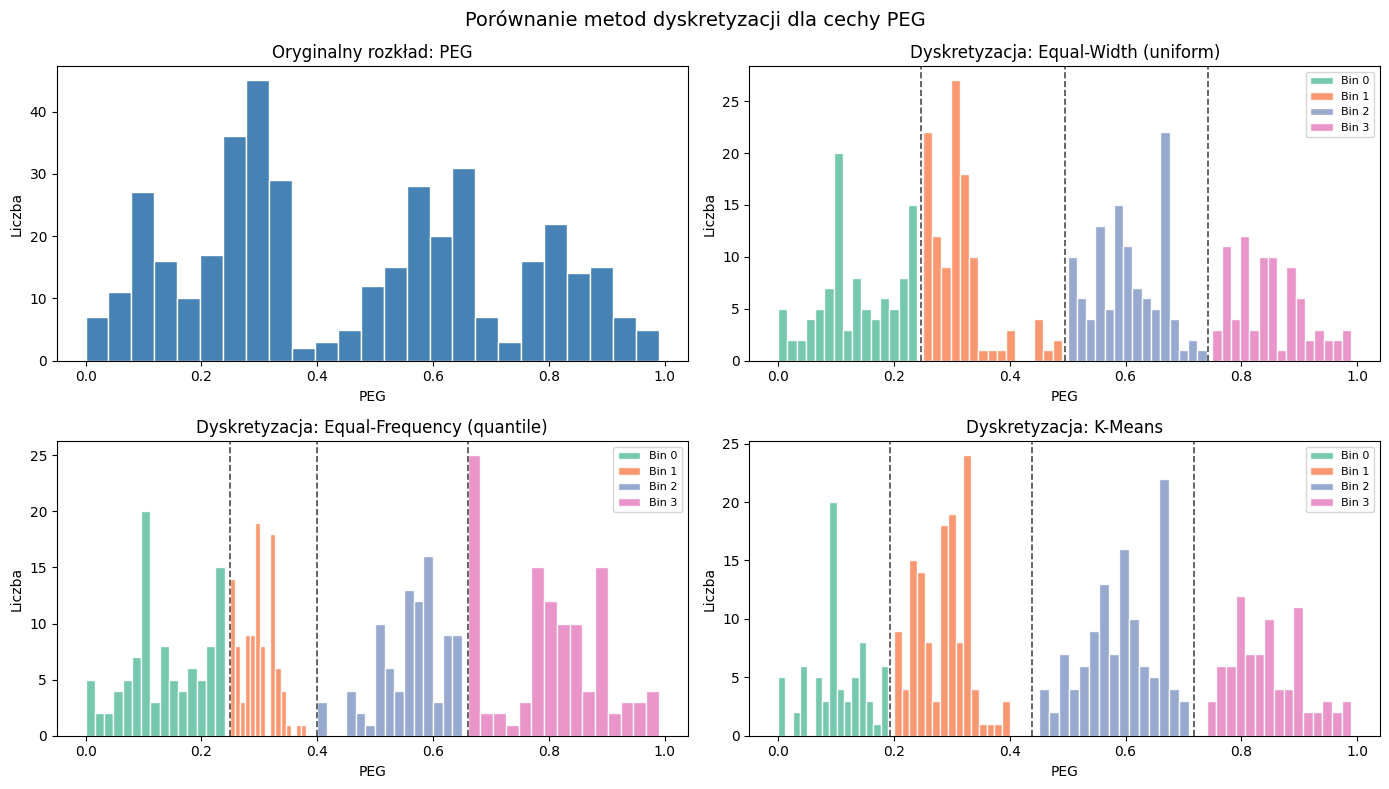

In [ ]:
# PORÓWNANIE METOD DYSKRETYZACJI
# Na potrzeby wizualizacji wybieram jedną zmienną ciągłą: PEG
# Jest ona bardzo istotna merytorycznie, bo opisuje wynik egzaminu z materiału głównego.

col_disc = "PEG"
#pobieram wartosci kolumny
#usuwam braki
#zamieniam na format wymagany przez sklearn: kolumna 2d
#KBinsDiscretizer - musi miec dane w postaci macierzy
data_disc = df[col_disc].dropna().values.reshape(-1, 1)
n_bins = 4
palette = sns.color_palette("Set2", n_bins)
#uniform - rowne szerokosci, quantile-rowne licznosci,kmeans-przedzialy oparte o grupowanie
#porownuje ktora metoda lepiej pasuje do moich danych
methods = ["uniform", "quantile", "kmeans"]
names   = ["Equal-Width (uniform)", "Equal-Frequency (quantile)", "K-Means"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# Oryginalny rozkład
axes[0].hist(df[col_disc].dropna(), bins=25, color="steelblue", edgecolor="white")
axes[0].set_title(f"Oryginalny rozkład: {col_disc}")
axes[0].set_xlabel(col_disc)
axes[0].set_ylabel("Liczba")

# Trzy metody dyskretyzacji
for idx, (method, name) in enumerate(zip(methods, names)):
  #tworze dyskretyzator - 4 przedzialy wynik to liczby
  #zamieniam ceche ciagla na przedzialy
    enc = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy=method)
    labels_b = enc.fit_transform(data_disc).astype(int).flatten()
    vals = df[col_disc].dropna().values

    for b in range(n_bins):
        axes[idx + 1].hist(
            vals[labels_b == b],
            bins=15,
            color=palette[b],
            edgecolor="white",
            alpha=0.9,
            label=f"Bin {b}"
        )

    for edge in enc.bin_edges_[0][1:-1]:
        axes[idx + 1].axvline(edge, color="black", linestyle="--", lw=1.2, alpha=0.7)

    axes[idx + 1].set_title(f"Dyskretyzacja: {name}")
    axes[idx + 1].set_xlabel(col_disc)
    axes[idx + 1].set_ylabel("Liczba")
    axes[idx + 1].legend(fontsize=8)

plt.suptitle(f"Porównanie metod dyskretyzacji dla cechy {col_disc}", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# MODEL NA DANYCH CIĄGŁYCH
# Najpierw sprawdzamy, jak działa drzewo decyzyjne
# na oryginalnych danych ciągłych.
#wybieram dane ciagle jako cechy wejsciowe - pkt. odniesienia - model bez dyskretyzacji
X_cont = df[["STG", "SCG", "STR", "LPR", "PEG"]].copy()
#kopia zakodowanej zmiennej docelowej
y_cont = y_encoded.copy()

X_train_cont, X_test_cont, y_train_cont, y_test_cont = train_test_split(
    X_cont,
    y_cont,
    test_size=0.25,
    stratify=y_cont,
    random_state=42
)

tree_cont = DecisionTreeClassifier(random_state=42)
tree_cont.fit(X_train_cont, y_train_cont)

y_pred_cont = tree_cont.predict(X_test_cont)

acc_cont = accuracy_score(y_test_cont, y_pred_cont)

print("Accuracy bez dyskretyzacji:", acc_cont)
print("\nRaport klasyfikacji dla modelu na danych ciągłych:")
print(classification_report(y_test_cont, y_pred_cont, target_names=le.classes_))

Accuracy bez dyskretyzacji: 0.9702970297029703

Raport klasyfikacji dla modelu na danych ciągłych:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        26
         Low       0.94      0.97      0.95        32
      Middle       0.97      0.94      0.95        31
    Very Low       1.00      1.00      1.00        12

    accuracy                           0.97       101
   macro avg       0.98      0.98      0.98       101
weighted avg       0.97      0.97      0.97       101



In [ ]:
# DYSKRETYZACJA WSZYSTKICH CECH
# Wybieram metodę "quantile", bo:
# 1. zachowuje podobną liczebność przedziałów,
# 2. jest stabilna dla małych zbiorów,
# 3. daje lepsze zbalansowanie niż uniform.

X_cont = df[["STG", "SCG", "STR", "LPR", "PEG"]].copy()
y = df["UNS"].copy()

discretizer = KBinsDiscretizer(
    n_bins=4,
    encode="ordinal",
    strategy="quantile"
)
#przeksztalcenie
X_disc = discretizer.fit_transform(X_cont)

# Zamiana z powrotem na DataFrame dla czytelności
X_disc = pd.DataFrame(X_disc, columns=X_cont.columns)

print("Podgląd danych po dyskretyzacji:")
print(X_disc.head())



Podgląd danych po dyskretyzacji:
   STG  SCG  STR  LPR  PEG
0  0.0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0  3.0
2  0.0  0.0  0.0  1.0  1.0
3  0.0  0.0  0.0  3.0  1.0
4  0.0  0.0  0.0  3.0  0.0


In [ ]:
# PODZIAŁ DANYCH
# Używamy stratyfikacji, aby zachować proporcje klas
# w zbiorze treningowym i testowym.

X_train, X_test, y_train, y_test = train_test_split(
    X_disc,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

print("Rozmiar zbioru treningowego:", X_train.shape)
print("Rozmiar zbioru testowego:", X_test.shape)

Rozmiar zbioru treningowego: (302, 5)
Rozmiar zbioru testowego: (101, 5)


In [ ]:
# BAZOWE DRZEWO DECYZYJNE
# Tworze bazowy model drzewa po dyskretyzacji.
# Nie ustawiam jeszcze finalnych parametrów, ponieważ później dobierze je metodą GridSearchCV.
#bazowe drzewko po dyskretyzacji
clf_base = DecisionTreeClassifier(random_state=42)
#ucze
clf_base.fit(X_train, y_train)
#przewiduje
y_pred_base = clf_base.predict(X_test)
#acc
acc_base = accuracy_score(y_test, y_pred_base)

print("Accuracy modelu bazowego:", acc_base)
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred_base, target_names=le.classes_))

Accuracy modelu bazowego: 0.7821782178217822

Raport klasyfikacji:
              precision    recall  f1-score   support

        High       0.89      0.92      0.91        26
         Low       0.71      0.78      0.75        32
      Middle       0.85      0.71      0.77        31
    Very Low       0.62      0.67      0.64        12

    accuracy                           0.78       101
   macro avg       0.77      0.77      0.77       101
weighted avg       0.79      0.78      0.78       101



In [ ]:
# WALIDACJA KRZYŻOWA

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    clf_base,
    X_disc,
    y_encoded,
    cv=cv,
    scoring="accuracy"
)

print("Wyniki accuracy dla poszczególnych foldów:")
print(cv_scores)

print("\nŚrednia accuracy:", round(cv_scores.mean(), 4))
print("Odchylenie standardowe:", round(cv_scores.std(), 4))

Wyniki accuracy dla poszczególnych foldów:
[0.72839506 0.80246914 0.85185185 0.8        0.8       ]

Średnia accuracy: 0.7965
Odchylenie standardowe: 0.0394


In [ ]:
# GRID SEARCH - DOBÓR PARAMETRÓW
#chce znalezc najlepsza konfiguracje drzewa wiec definiuje siatke parametrow do przeszukania
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    #optymalizacja pod acc
    scoring="accuracy",
    #walidacja 5-fold
    cv=cv,
    #uzycie wszystkich rdzeni
    n_jobs=-1
)
#przeszukaj parametry
grid.fit(X_train, y_train)

print("Najlepsze parametry:", grid.best_params_)
print("Najlepszy wynik CV:", grid.best_score_)

Najlepsze parametry: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Najlepszy wynik CV: 0.8212021857923497


In [ ]:
# FINALNY MODEL
#najlepszy model stosuje z gridsearchcv
best_clf = grid.best_estimator_

y_pred = best_clf.predict(X_test)

acc_final = accuracy_score(y_test, y_pred)

print("Accuracy na zbiorze testowym:", acc_final)
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy na zbiorze testowym: 0.8613861386138614

Raport klasyfikacji:
              precision    recall  f1-score   support

        High       0.89      0.96      0.93        26
         Low       0.76      1.00      0.86        32
      Middle       0.96      0.77      0.86        31
    Very Low       1.00      0.50      0.67        12

    accuracy                           0.86       101
   macro avg       0.90      0.81      0.83       101
weighted avg       0.88      0.86      0.85       101



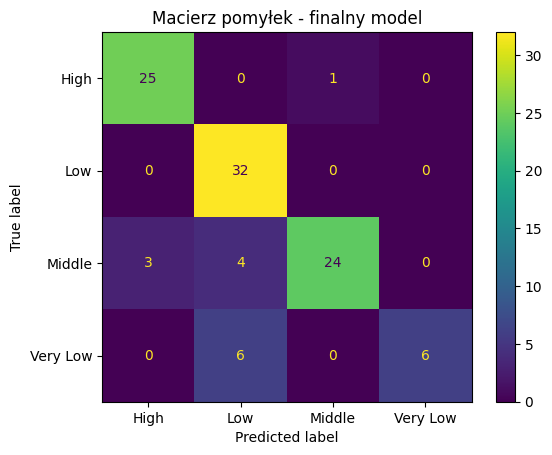

In [ ]:
# MACIERZ POMYŁEK

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(values_format="d")
plt.title("Macierz pomyłek - finalny model")
plt.show()

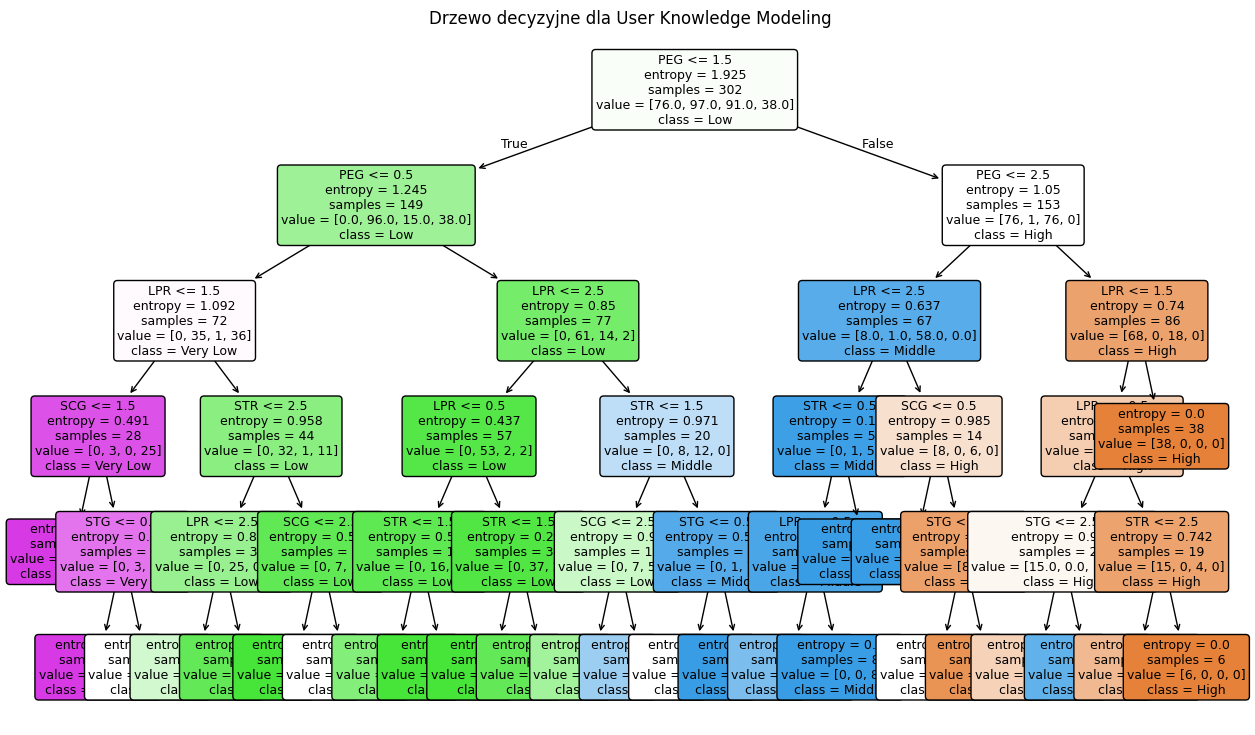

In [ ]:
# WIZUALIZACJA DRZEWA

plt.figure(figsize=(15, 9))
plot_tree(
    best_clf,
    #nazwy cech
    feature_names=X_disc.columns,
    #nazwy klas
    class_names=le.classes_,
    #kolorki do wezlow
    filled=True,
    #zaokraglone ramki
    rounded=True,
    fontsize=9
)

plt.title("Drzewo decyzyjne dla User Knowledge Modeling")
plt.show()

Ważność cech w modelu:

PEG    0.705882
LPR    0.202765
STR    0.041231
SCG    0.028333
STG    0.021789
dtype: float64


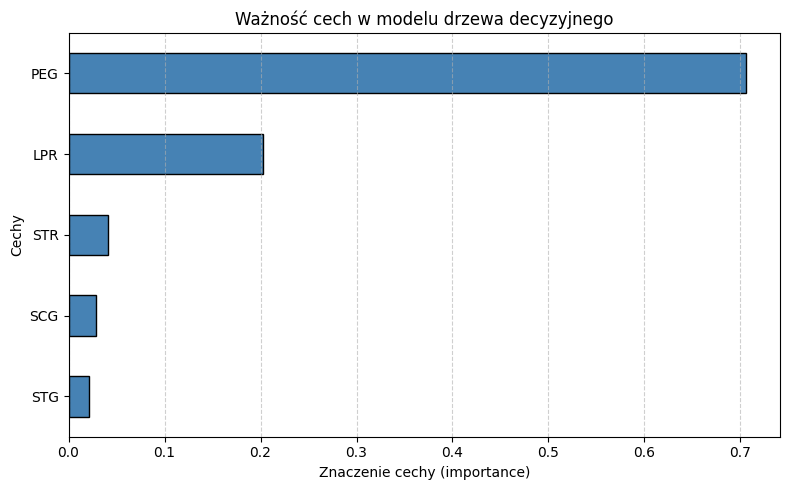

In [ ]:
# WAŻNOŚĆ CECH
#pobieram waznosci cech z modelu
#tworze serie z nazwami kolumn
#sortuje rosnaco
#by zobaczyc ktore cechy rzeczywisciew sa najwazniejszew
feature_importance = pd.Series(
    best_clf.feature_importances_,
    index=X_disc.columns
).sort_values(ascending=True)

print("Ważność cech w modelu:\n")
print(feature_importance.sort_values(ascending=False))

# Wykres ważności cech
plt.figure(figsize=(8, 5))
#poziomy wykres by ladnie wizualizowal
feature_importance.plot(
    kind="barh",
    color="steelblue",
    edgecolor="black"
)

plt.title("Ważność cech w modelu drzewa decyzyjnego", fontsize=12)
plt.xlabel("Znaczenie cechy (importance)")
plt.ylabel("Cechy")
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# PORÓWNANIE MODELI
#tworzenie tabeli porownawczej
#model na danych ciaglych
#model bazowy po dyskretyzacji
#model finalny po gridsearch
#by zobaczyc wplyw dyskretynizacji i strojenia
comparison = pd.DataFrame({
    "Model": [
        "Drzewo na danych ciągłych",
        "Drzewo po dyskretyzacji (bazowe)",
        "Drzewo po dyskretyzacji + GridSearch"
    ],
    "Accuracy": [
        acc_cont,
        acc_base,
        acc_final
    ]
})

print(comparison)

                                  Model  Accuracy
0             Drzewo na danych ciągłych  0.970297
1      Drzewo po dyskretyzacji (bazowe)  0.782178
2  Drzewo po dyskretyzacji + GridSearch  0.861386


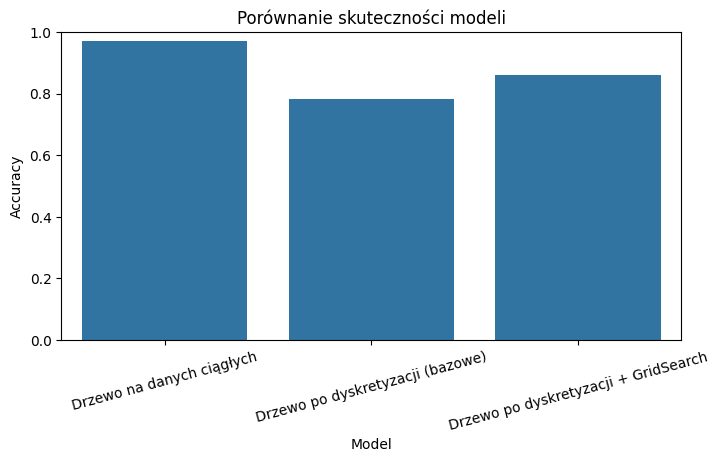

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(data=comparison, x="Model", y="Accuracy")
plt.title("Porównanie skuteczności modeli")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()